In [1]:
import os
#os.environ["JAX_PLATFORM_NAME"] = "cpu"
#os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'

In [2]:
import os
import sys
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
from diffrax import RecursiveCheckpointAdjoint
from jaxpm.distributed import normal_field

parent_dir = os.path.abspath("../content")
sys.path.append(parent_dir)

from tools.lensing_model import (
    Configurations,
    Planck18,
    full_field_probmodel,
    make_full_field_model,
)

os.environ["EQX_ON_ERROR"] = "nan"
os.environ["JC_CACHE"] = "off"
jax.config.update("jax_enable_x64", True)

In [3]:
from jax.sharding import NamedSharding
from jax.sharding import PartitionSpec as P

pdims = (4 , 2)
if jax.device_count() > 1:
    mesh = jax.make_mesh(pdims, ("x", "y"))
    sharding = NamedSharding(mesh, P("x", "y"))
else:
    sharding = None

In [7]:
box_shape = (256, 256, 512)
box_size = [800.0, 800.0, 4000.0]
field_npix = 256  # number of pixels per side
field_size = 9 * field_npix / 60  # transverse size in degrees
density_plane_width = 100
density_plane_npix = 256  # updated number of pixels for density plane
density_plane_smoothing = 0.1
t0 = 0.1
t1 = 1.0
dt0 = 0.1
# Define the fiducial cosmology
cosmo = Planck18()

Pixel size in arcmin:  9.0


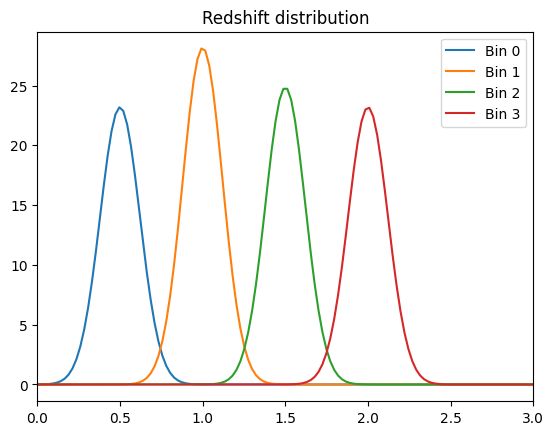

In [8]:
from scipy.stats import norm

max_comoving_distance = box_size[2]  # in Mpc/h
max_redshift = (1 / jc.background.a_of_chi(cosmo, max_comoving_distance) - 1).squeeze()
z = jnp.linspace(0, max_redshift, 1000)

nz_shear = [
    jc.redshift.kde_nz(
        z, norm.pdf(z, loc=z_center, scale=0.12), bw=0.01, zmax=max_redshift, gals_per_arcmin2=g
    )
    for z_center, g in zip([0.5, 1.0, 1.5, 2.0], [7, 8.5, 7.5, 7])
]
nbins = len(nz_shear)


# Specify the size and resolution of the patch to simulate
sigma_e = 0.3
print("Pixel size in arcmin: ", field_size * 60 / field_npix)

# Plotting the redshift distribution
z = np.linspace(0, 3.0, 128)

for i in range(nbins):
    plt.plot(
        z,
        nz_shear[i](z) * nz_shear[i].gals_per_arcmin2,
        color=f"C{i}",
        label=f"Bin {i}",
    )
plt.legend()
plt.xlim(0, 3)
plt.title("Redshift distribution")
plt.show()

In [9]:
forward_model = make_full_field_model(
        field_size=field_size,
        field_npix=field_npix,
        box_shape=box_shape,
        box_size=box_size,
        density_plane_width=density_plane_width,
        density_plane_npix=density_plane_npix,
        density_plane_smoothing=density_plane_smoothing,
        adjoint=RecursiveCheckpointAdjoint(checkpoints=4),
        t0=t0,
        t1=t1,
        dt0=dt0,
        max_redshift=max_redshift,
        sharding=sharding,
        halo_size=0 if sharding is None else box_shape[0] // 8,
    )

In [7]:
initial_conditions = normal_field(jax.random.key(0) , box_shape , sharding=sharding)
kappas, lc , ic = forward_model(cosmo, nz_shear, initial_conditions)

In [14]:
def model(initial_conditions, kappas):
    kappas_rev, _ , _ = forward_model(
        cosmo, nz_shear, initial_conditions)
    mse = jax.tree.map(
        lambda x, y: jnp.mean((x - y) ** 2), kappas, kappas_rev
    )
    return sum(jax.tree.leaves(mse))

grads = jax.grad(model)(initial_conditions, kappas)

print(f"Initial conditions sharding")
jax.debug.visualize_array_sharding(initial_conditions[...,0])
print(f"Grads sharding")
jax.debug.visualize_array_sharding(grads[...,0])

Initial conditions sharding


                        
   GPU 0       GPU 1    
                        
                        
   GPU 2       GPU 3    
                        
                        
   GPU 4       GPU 5    
                        
                        
   GPU 6       GPU 7    
                        

Grads sharding


                        
   GPU 0       GPU 1    
                        
                        
   GPU 2       GPU 3    
                        
                        
   GPU 4       GPU 5    
                        
                        
   GPU 6       GPU 7    
                        

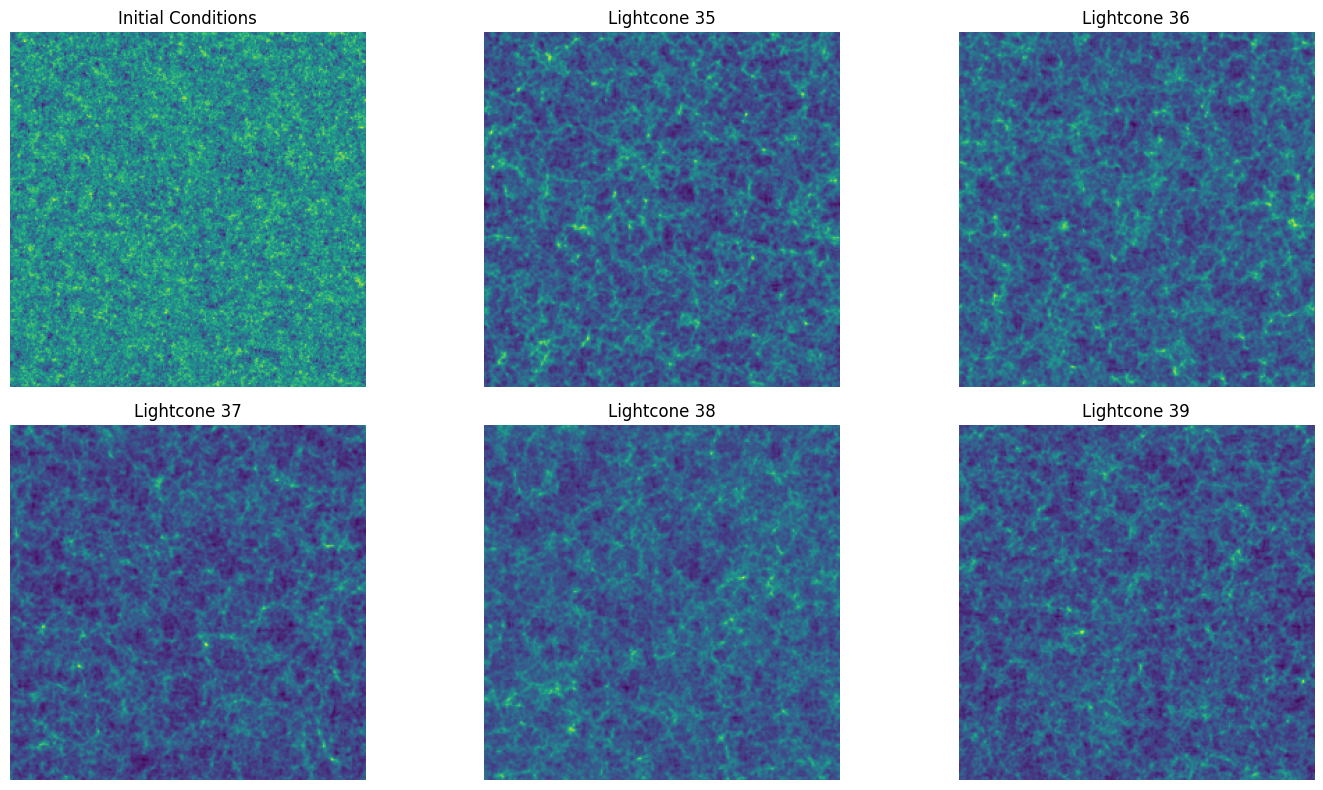

In [20]:
n_planes = lc.shape[2]
n_total = n_planes + 1  # includes IC slice
ncols = 3
nrows = min(2 , (n_total + ncols - 1) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))

# Flatten axes for easy indexing
axes = axes.flatten()

# Plot initial conditions (last slice)
axes[0].imshow(ic[...,-1], cmap="viridis")
axes[0].set_title("Initial Conditions")
axes[0].axis("off")

# Plot each lightcone plane
for i in range(n_planes - 5 , n_planes):
    if i <= 0 or i >= n_planes:
        continue
    idx = i - n_planes + 5
    axes[idx + 1].imshow(lc[..., i], cmap="viridis")
    axes[idx + 1].set_title(f"Lightcone {i}")
    axes[idx + 1].axis("off")
    axes[idx + 1].axis("off")


plt.tight_layout()
plt.show()

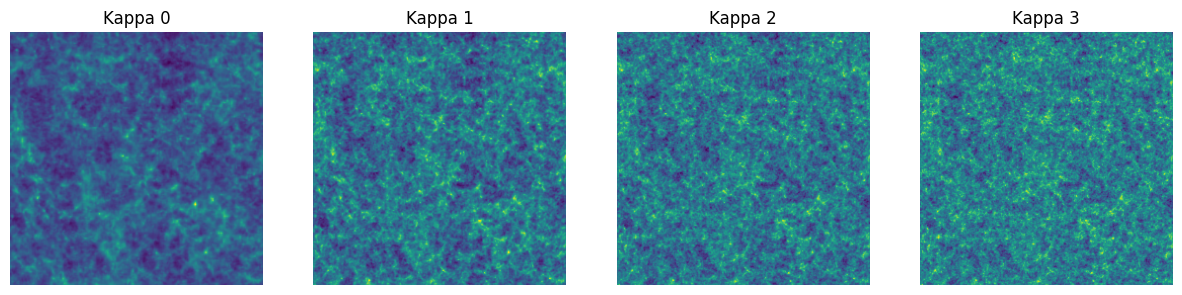

In [18]:
plt.figure(figsize=(15,15))
for i in range(nbins):
    plt.subplot(1 , nbins , i + 1)
    plt.imshow(kappas[i])
    plt.title(f"Kappa {i}")
    plt.axis("off")

In [14]:
import jax.numpy as jnp
from tools.lensing_model import make_2pt_model
# Define multipoles ℓ
ell = jnp.linspace(50, 1000, 20)

# Define pixel scale in arcminutes
pixel_scale = field_size * 60 / field_npix  # same as used in simulations

# Define your redshift distributions (as in the simulation)
z_2pt = jnp.linspace(0, 2.5, 1000)
from scipy.stats import norm
nz_shear_2pt = [
    jc.redshift.kde_nz(z_2pt, norm.pdf(z_2pt, loc=z0, scale=0.12), bw=0.01, zmax=2.5, gals_per_arcmin2=g)
    for z0, g in zip([0.5, 1.0, 1.5, 2.0], [7, 8.5, 7.5, 7])
]


cl_model = make_2pt_model(pixel_scale=pixel_scale, ell=ell, sigma_e=0.3)

# Use Planck18 or your own cosmology instance
cosmo = Planck18()

# Compute theoretical signal and noise Cls
cl_signal, cl_noise = cl_model(cosmo, nz_shear_2pt)

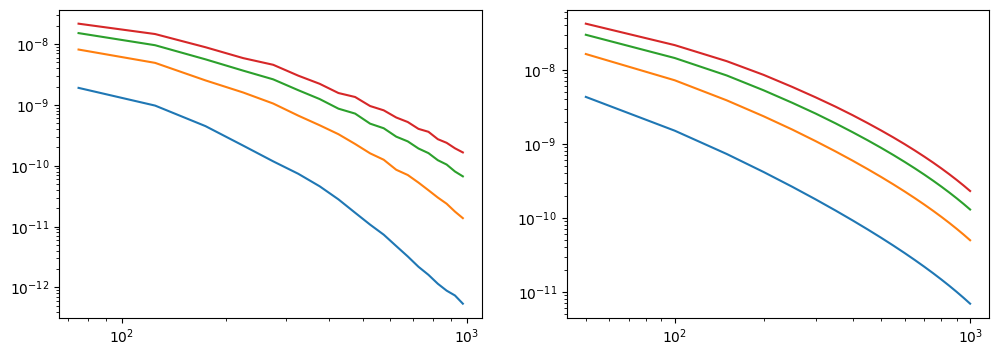

In [15]:
import itertools
from lenstools import ConvergenceMap
import astropy.units as u
k = 0.5 * (ell[1:] + ell[:-1]) 

plt.figure(figsize=(12, 4))
# Compute the auto power spectrum for each bin
simu_auto_cl = [ConvergenceMap(kappas[idx], angle=field_size*u.deg).powerSpectrum(ell)[1] for idx in range(nbins)]
plt.subplot(1, 2, 1)
plt.loglog(k , np.array(simu_auto_cl).T)
# Recover the theoretical Cls for the auto-correlations
bin_pairs = list(itertools.combinations_with_replacement(range(4), 2))
theory_auto_cl = [cl_signal[bin_pairs.index((id , id))] for id in range(nbins)]
plt.subplot(1, 2, 2)
plt.loglog(ell , np.array(theory_auto_cl).T)
plt.show()

In [23]:
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import condition, seed, trace
from numpyro.infer import MCMC, NUTS

# condition the model on a given set of parameters
fiducial_cosmology = Planck18()

config = Configurations(
    field_size=field_size,
    field_npix=field_npix,
    box_shape=box_shape,
    box_size=box_size,
    density_plane_width=density_plane_width,
    density_plane_npix=density_plane_npix,
    density_plane_smoothing=density_plane_smoothing,
    nz_shear=nz_shear,
    fiducial_cosmology=Planck18,
    sigma_e=sigma_e,
    priors={
        "Omega_c": dist.Uniform(0.2, 0.4),
        "sigma8": dist.Uniform(0.6, 1.0),
    },
    t0=t0,
    t1=t1,
    dt0=dt0,
    max_redshift=max_redshift,
    sharding=sharding,
    halo_size=box_shape[0] // 8,
)

full_field_basemodel = full_field_probmodel(config)

fiducial_model = condition(
    full_field_basemodel,
    {"Omega_c": fiducial_cosmology.Omega_c, "sigma8": fiducial_cosmology.sigma8 , "initial_conditions" : initial_conditions },
)


# sample a mass map and save corresponding true parameters
model_trace = trace(seed(fiducial_model, 0)).get_trace()
print(f"Logged parameters: {model_trace.keys()}")

Logged parameters: odict_keys(['Omega_c', 'sigma8', 'initial_conditions', 'lightcone', 'ic', 'kappa_0', 'kappa_1', 'kappa_2', 'kappa_3'])


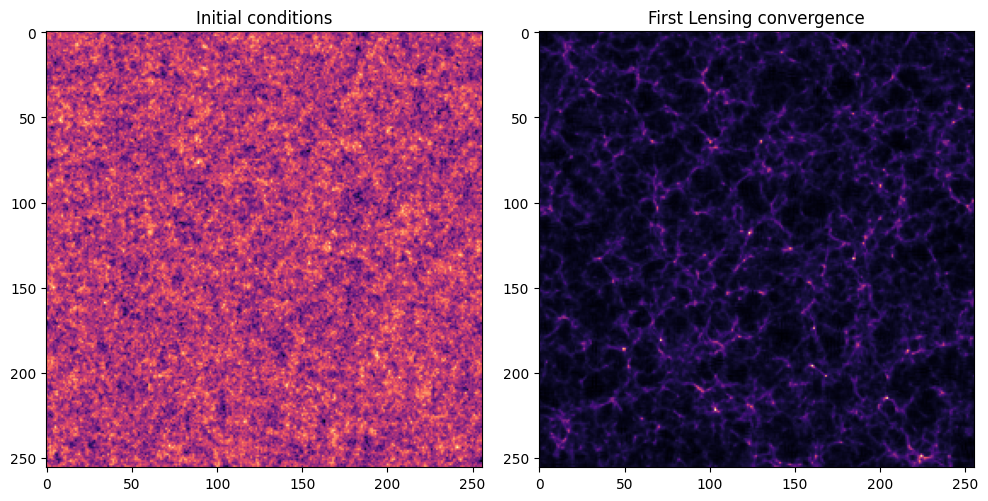

In [24]:
z_axis = box_shape[2]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(model_trace["ic"]["value"][...,3*z_axis//4], cmap="magma")
plt.title("Initial conditions")
plt.subplot(1, 2, 2)
plt.imshow(model_trace["lightcone"]["value"][...,0], cmap="magma")
plt.title("First Lensing convergence")
plt.tight_layout()
plt.show()


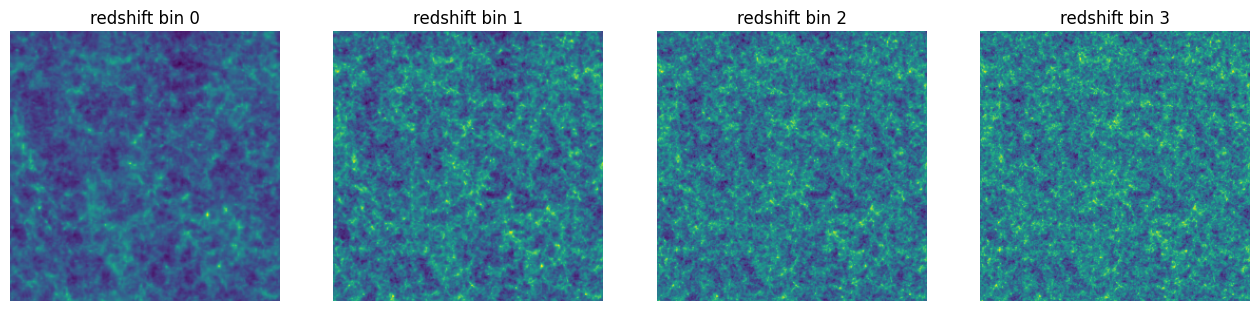

In [25]:

plt.figure(figsize=[16,4])
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.title('redshift bin %d'%i)
    plt.imshow(model_trace[f"kappa_{i}"]["fn"].mean, cmap="viridis")
    plt.axis('off')

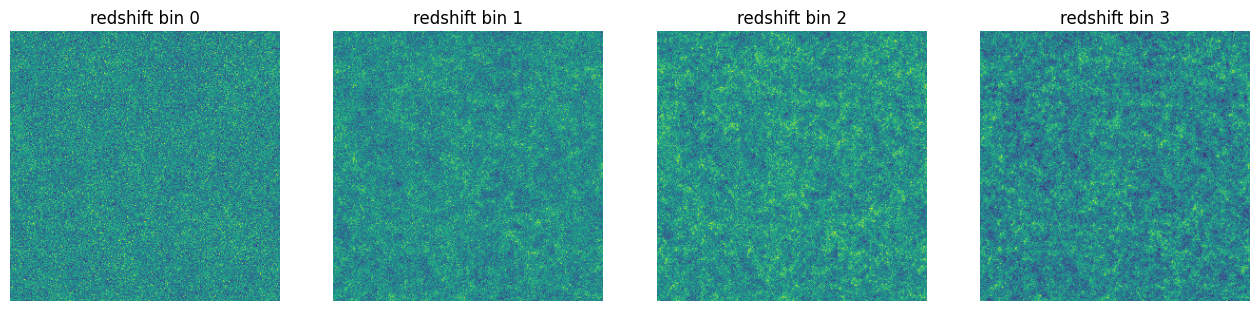

In [26]:

plt.figure(figsize=[16,4])
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.title('redshift bin %d'%i)
    plt.imshow(model_trace[f"kappa_{i}"]["value"], cmap="viridis")
    plt.axis('off')

In [27]:
# Let's condition the model on the observed maps
observed_model = condition(
    full_field_basemodel,
    {
        "kappa_0": model_trace["kappa_0"]["value"],
        "kappa_1": model_trace["kappa_1"]["value"],
        "kappa_2": model_trace["kappa_2"]["value"],
        "kappa_3": model_trace["kappa_3"]["value"],
    },
)

In [28]:
nuts_kernel = NUTS(
    model=observed_model,
    init_strategy=partial(
        numpyro.infer.init_to_value,
        values={
            "Omega_c": cosmo.Omega_c,
            "sigma8": cosmo.sigma8,
            "initial_conditions": model_trace["initial_conditions"]["value"],
        },
    ),
    max_tree_depth=3,
    step_size=0.05,
)

In [29]:
mcmc = MCMC(
    nuts_kernel,
    num_warmup=10,
    num_samples=10,
    # num_chains=5,
    # chain_method='vectorized',
    thinning=1,
    progress_bar=True,
)

mcmc.run(jax.random.PRNGKey(0))

sample: 100%|██████████| 20/20 [18:12<00:00, 54.60s/it, 7 steps of size 7.71e-05. acc. prob=0.73]  


In [ ]:
os.makedirs("multi", exist_ok=True)
np.savez("multi/mcmc_samples.npz", **mcmc.get_samples())
kappa_keys = [f"kappa_{i}" for i in range(nbins)]
true_kappas = {key: model_trace[key]["fn"].mean for key in kappa_keys}
np.savez(
    "multi/true_kappas.npz",
    **true_kappas,
)

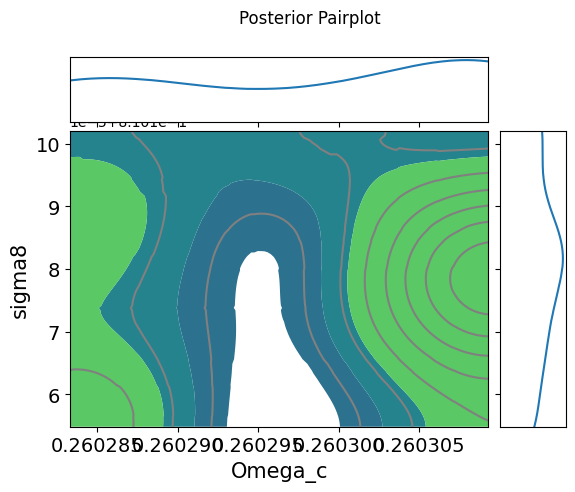

In [5]:
import arviz as az
samples = dict(np.load("multi/mcmc_samples.npz"))
true_kappas = dict(np.load("multi/true_kappas.npz"))

scalar_keys = [k for k in samples.keys() if samples[k].ndim == 1]
scalar_samples = {k: samples[k] for k in scalar_keys}

az_data = az.from_dict(posterior=scalar_samples)
az.plot_pair(az_data, kind="kde", marginals=True)
plt.suptitle("Posterior Pairplot")
plt.show()

Plotting Initial Conditions (IC)...


<Figure size 1000x500 with 0 Axes>

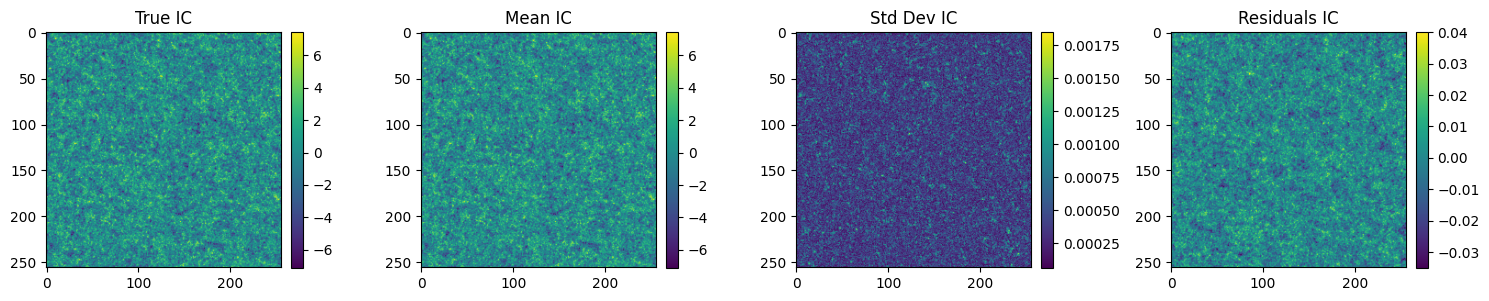

In [10]:
slice_true_ic = ic[..., -1]  # Last slice of the initial conditions
mean_ic = samples["ic"].mean(axis=0)[..., -1]  # Last slice of the mean initial conditions
std_ic = samples["ic"].std(axis=0)[..., -1]  # Last slice of the mean initial conditions
residual_ic = mean_ic - slice_true_ic
plt.figure(figsize=(10, 5))

print("Plotting Initial Conditions (IC)...")
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, img, title in zip(
    axes,
    [slice_true_ic, mean_ic, std_ic, residual_ic],
    ["True IC", "Mean IC", "Std Dev IC", "Residuals IC"],
):
    im = ax.imshow(img, cmap="viridis")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [11]:
inferred_cosmo = Planck18(
    Omega_c=samples["Omega_c"].mean(),
    sigma8=samples["sigma8"].mean(),
)

saved_initial_conditions = samples["initial_conditions"].mean(axis=0)
if sharding is not None:
    # Ensure the initial conditions are sharded correctly
    saved_initial_conditions = jax.lax.with_sharding_constraint(saved_initial_conditions, sharding)
recovered_kappas , _ , _ = forward_model(
    inferred_cosmo, nz_shear, saved_initial_conditions
)

In [ ]:
recovered_kappas_dict = {key: recovered_kappas[i] for i , key in enumerate(kappa_keys)}
np.savez(
    "multi/recovered_kappas.npz",
    **recovered_kappas_dict,
)

Plotting Kappa Maps...


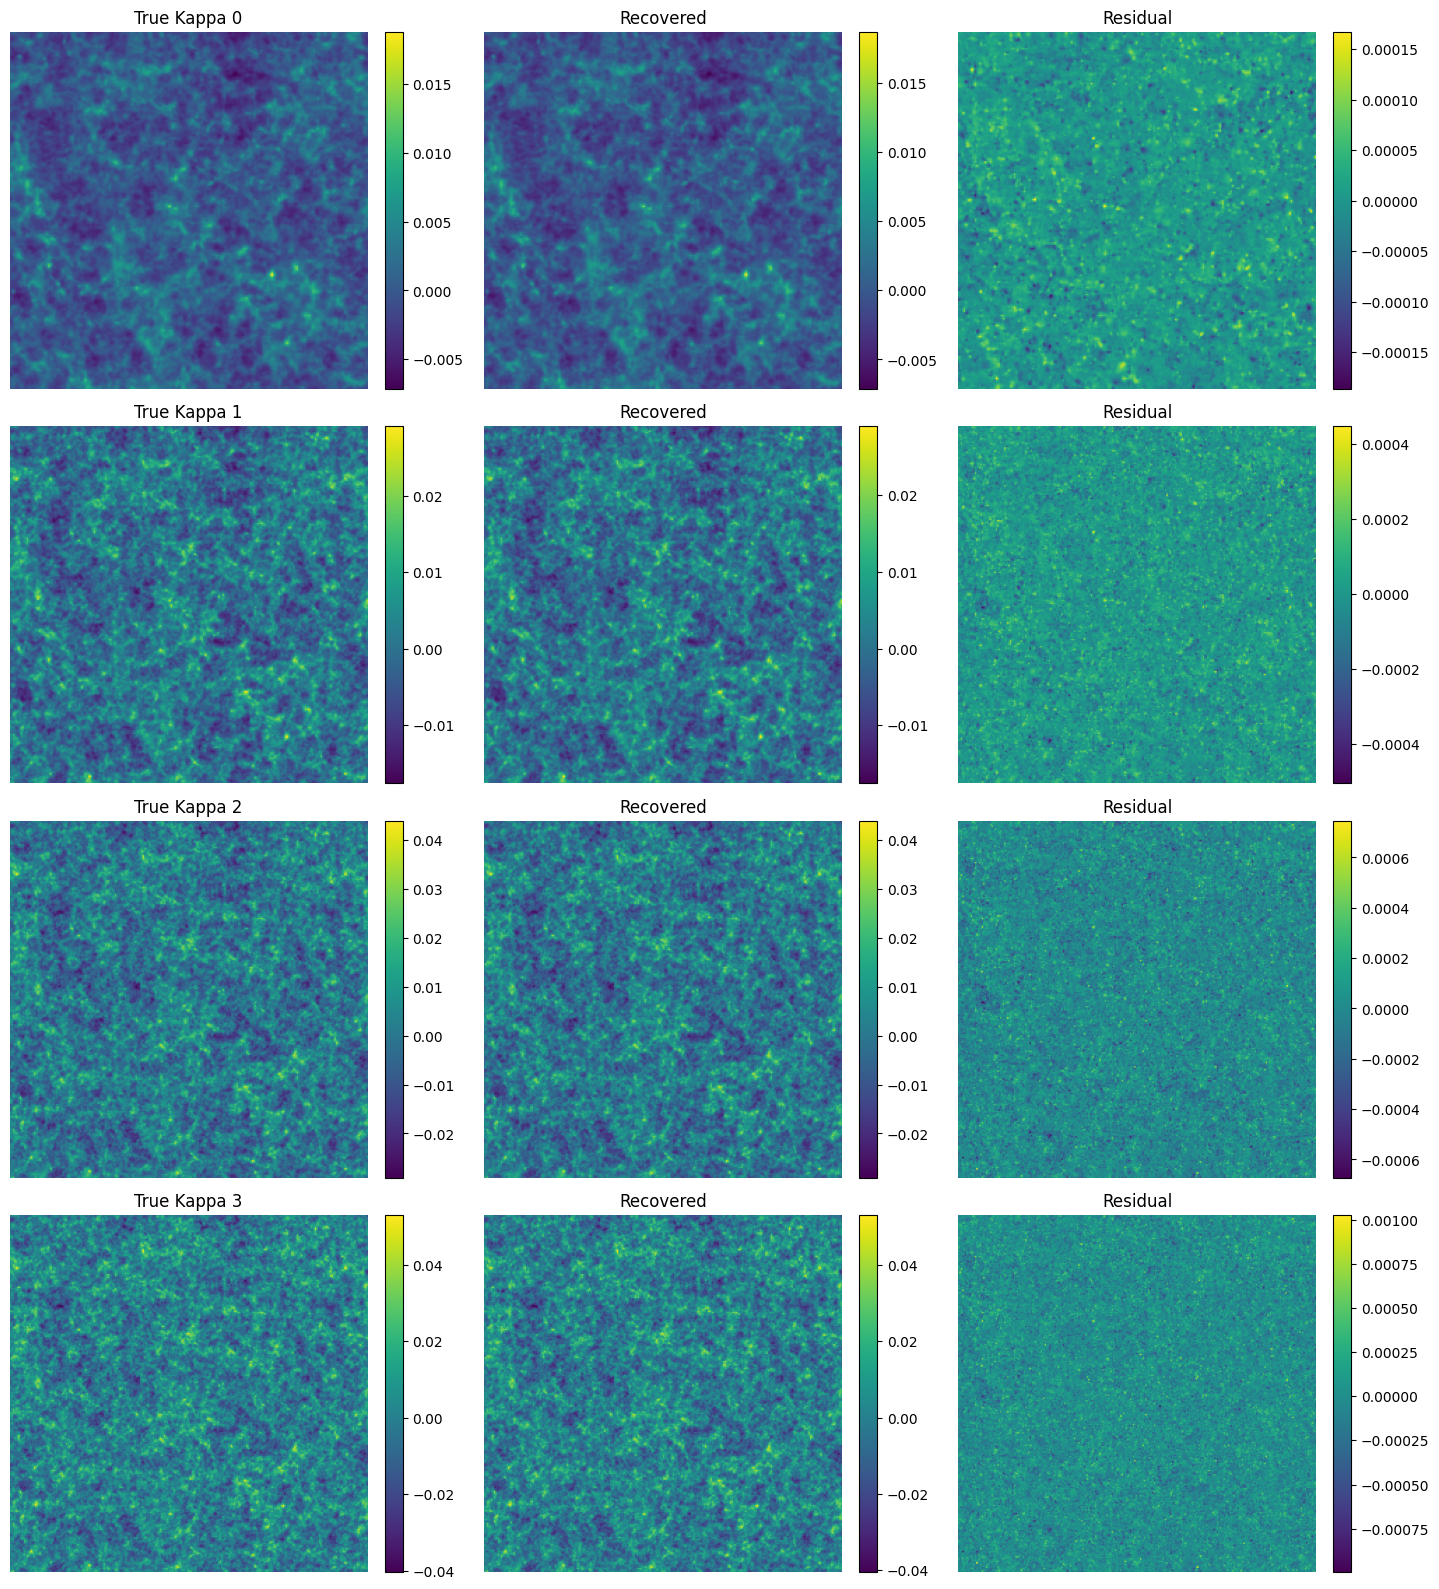

In [10]:
# Plot kappa maps (each redshift bin)
kappa_keys = [f"kappa_{i}" for i in range(nbins)]
print("Plotting Kappa Maps...")
recovered_kappas = dict(np.load("multi/recovered_kappas.npz"))
recovered_kappas = [recovered_kappas[key] for key in kappa_keys]

fig, axes = plt.subplots(nbins, 3, figsize=(15, 4 * nbins))

# Ensure axes is 2D even if nbins == 1
if nbins == 1:
    axes = axes[np.newaxis, :]

for i, key in enumerate(kappa_keys):
    true_kappa = true_kappas[key]
    recovered_kappa = recovered_kappas[i]
    residual_kappa = recovered_kappa - true_kappa

    for ax, img, title in zip(
        axes[i],
        [true_kappa, recovered_kappa, residual_kappa],
        [f"True Kappa {i}", "Recovered", "Residual"],
    ):
        im = ax.imshow(img, cmap="viridis")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title)
        ax.axis('off')

plt.tight_layout()
plt.show()


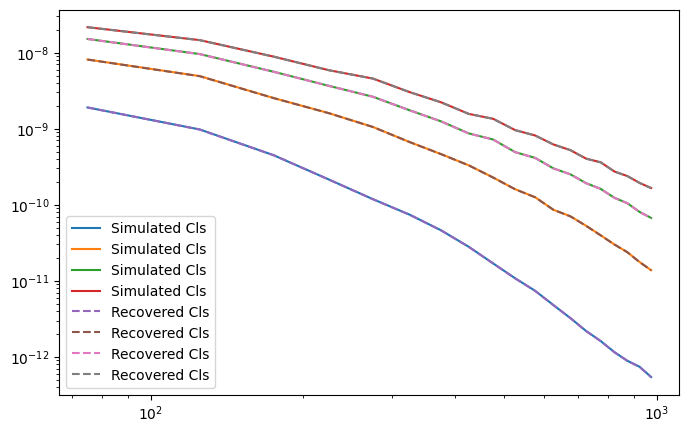

In [11]:
from lenstools import ConvergenceMap
import astropy.units as u

ell = jnp.linspace(50, 1000, 20)


k = 0.5 * (ell[1:] + ell[:-1]) 

simu_auto_cl = [ConvergenceMap(list(true_kappas.values())[idx], angle=field_size*u.deg).powerSpectrum(ell)[1] for idx in range(nbins)]
recovered_kappa = [ConvergenceMap(recovered_kappas[idx], angle=field_size*u.deg).powerSpectrum(ell)[1] for idx in range(nbins)]
plt.figure(figsize=(8, 5))
plt.loglog(k , np.array(simu_auto_cl).T, label="Simulated Cls")
plt.loglog(k , np.array(recovered_kappa).T, label="Recovered Cls", linestyle='--')
plt.legend()

plt.show()